# Χαρτογράφηση Κάλυψης Κεραίας με Επιφάνεια Ισοϋψών Απώλειας Διαδρομής


## Σύνοψη

Μια ομάδα σχεδιασμού ραδιοσυχνοτήτων (RF) τηλεπικοινωνιών αποτυπώνει την **επιφάνεια απώλειας διαδρομής καθόδου** γύρω από ένα μεμονωμένο μακροκύτταρο ως δισδιάστατο χάρτη κάλυψης. Χρησιμοποιώντας ένα μοντέλο διάδοσης λογαριθμικής απόστασης με λογαριθμοκανονική διαλείπουσα σκίαση (shadow fading), αυτό το notebook κατασκευάζει ένα πλέγμα μέτρησης 100 σημείων (10 x 10 κελιά που καλύπτουν μια περιοχή εξυπηρέτησης 10 km x 10 km, με τον πύργο στο κέντρο) και σχεδιάζει μια συμπαγή επιφάνεια ισοϋψών με **PROC SGPLOT HEATMAPPARM** μαζί με διαβαθμισμένη χρωματική κλίμακα και γραμμές αναφοράς πύργου.

Στο εκτελεσμένο πλέγμα η απώλεια διαδρομής κυμαίνεται από **50.4 dB** (στη φωτεινή λεκάνη στον πύργο) έως **90.0 dB** στην πιο απομακρυσμένη γωνία, με μέσο όρο **75.6 dB**. Η ταξινόμηση κάθε κελιού βάσει της απώλειάς του δίνει 38 κελιά στην κατηγορία «Ισχυρή», 61 στην κατηγορία «Επαρκής», και 1 στην κατηγορία «Ασθενής»· το μοναδικό κελί «Ασθενής» βρίσκεται στα **(9.5, 9.5) km — τη γωνία διαγώνια απέναντι από τον πύργο — στα 89.97 dB**, τη μοναδική τρύπα κάλυψης που θα επισήμαινε ένας σχεδιαστής πριν από μια απόφαση συμπλήρωσης με μικροκύτταρο (small-cell infill).

> **Σημείωση σχετικά με τη διαδικασία.** Στη SAS το κλασικό εργαλείο για χάρτες ισοϋψών καμπυλών είναι η `PROC GCONTOUR`. Η Jenner αναλύει τη GCONTOUR και παράγει μια σωστή προδιαγραφή γραφήματος, αλλά ο μηχανισμός ραστεροποίησής της δεν σχεδιάζει ακόμη τη γεωμετρία των ισοϋψών (η εικόνα επιστρέφει κενή)· αυτό το ελάττωμα είναι καταγεγραμμένο ως δοκιμή παλινδρόμησης `tests/400922_nb_gcontour_empty_render`. Για να διατηρήσουμε αυτό το παράδειγμα πλήρως θεμελιωμένο σε ένα πραγματικά αποδοσμένο σχήμα, χρησιμοποιούμε το συμβατό με SAS ισοδύναμο — την `PROC SGPLOT` με δήλωση `HEATMAPPARM` — η οποία αποδίδει την ίδια πλεγματική επιφάνεια (x, y, z) ως συμπαγή κελιά ισοϋψών με διαβαθμισμένο υπόμνημα.

## Πηγές Δεδομένων

**Συνθετικό σύνολο δεδομένων: `pathloss_grid`** (100 γραμμές — πλέγμα 10 x 10)

| Μεταβλητή | Τύπος | Μονάδες | Περιγραφή |
|----------|------|-------|-------------|
| `east_km` | αριθμ. | km | Ανατολική συντεταγμένη του κέντρου του κελιού πλέγματος (0.5 έως 9.5)· άξονας x |
| `north_km` | αριθμ. | km | Βόρεια συντεταγμένη του κέντρου του κελιού πλέγματος (0.5 έως 9.5)· άξονας y |
| `path_loss` | αριθμ. | dB | Απώλεια διαδρομής καθόδου = 58 + 30 log10(απόσταση) + σκίαση· η απόκριση (z) |
| `zone` | χαρ.(20) | — | Κατηγορία κάλυψης: Ισχυρή (<=75), Επαρκής (<=88), Ασθενής (>88) |

Ο πύργος βρίσκεται στο κέντρο του πλέγματος **(5, 5) km**. Η απώλεια διαδρομής αυξάνεται με τον λογάριθμο βάσης 10 της απόστασης από τον πύργο· ένας όρος σκίασης `3*rand("normal")` (seed 80211) εισάγει λογαριθμοκανονική διαλείπουσα σκίαση ώστε οι ισοϋψείς να μην είναι τέλεια κυκλικές. Το πλέγμα 10 x 10 έχει μέγεθος ώστε ολόκληρη η επιφάνεια να χωράει σε 100 παρατηρήσεις.

## Βήμα 1 — Δημιουργία του πλέγματος μέτρησης

Τοποθετούμε ένα πλέγμα 1 km με κέντρα κελιών και υπολογίζουμε την απώλεια διαδρομής με το **μοντέλο λογαριθμικής απόστασης** `PL = 58 + 30 log10(d)`, όπου `d` είναι η απόσταση από τον πύργο στα (5, 5) km. Ένας όρος διαλείπουσας σκίασης `rand("normal")` αναπαράγει τη μεταβλητότητα που παρατηρείται σε πραγματικές μετρήσεις οδήγησης (drive-tests). Κάθε κελί ταξινομείται σε μια `zone` κάλυψης. Η `call streaminit` σταθεροποιεί τον σπόρο (seed) για αναπαραγωγιμότητα.

In [1]:
ΔΕΔΟΜΕΝΑ pathloss_grid;
   CALL streaminit(80211);
   LENGTH zone $20;
   tower_x = 5.0;  tower_y = 5.0;
   ΕΠΑΝΑΛΗΨΗ ix = 1 ΕΩΣ 10;
      ΕΠΑΝΑΛΗΨΗ iy = 1 ΕΩΣ 10;
         east_km  = ix - 0.5;          /* 0.5 .. 9.5 km */
         north_km = iy - 0.5;          /* 0.5 .. 9.5 km */
         DIST = sqrt((east_km-tower_x)**2 + (north_km-tower_y)**2) + 0.4;
         shadow = 3*rand("normal");
         path_loss = 58 + 30*log10(DIST) + shadow;
         ΕΑΝ      path_loss <= 75 ΤΟΤΕ zone = "Ισχυρή";
         ΑΛΛΙΩΣ ΕΑΝ path_loss <= 88 ΤΟΤΕ zone = "Επαρκής";
         ΑΛΛΙΩΣ                         zone = "Ασθενής";
         ΕΞΟΔΟΣ;
      ΤΕΛΟΣ;
   ΤΕΛΟΣ;
   ΑΦΑΙΡΕΣΗ ix iy tower_x tower_y DIST shadow;
   ΕΤΙΚΕΤΑ east_km   = "Ανατολικά (km)"
         north_km  = "Βόρεια (km)"
         path_loss = "Απώλεια Διαδρομής (dB)"
         zone      = "Ζώνη Κάλυψης";
ΕΚΤΕΛΕΣΗ;


NOTE: DATA pathloss_grid


NOTE: Wrote pathloss_grid (100 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Βήμα 2 — Σύνοψη της επιφάνειας

Πριν από τη σχεδίαση, ποσοτικοποιούμε την επιφάνεια. Η `PROC MEANS` αναφέρει το δυναμικό εύρος της απώλειας διαδρομής και η `PROC FREQ` καταγράφει πώς τα 100 κελιά κατανέμονται στις τρεις κατηγορίες κάλυψης — τους αριθμούς που παραθέτει η συνοπτική επισκόπηση.

In [2]:
ODS GRAPHICS OFF;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=pathloss_grid MIN MAX mean maxdec=1;
   ΜΕΤΑΒΛΗΤΗ path_loss;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=pathloss_grid ORDER=ΣΥΧΝΟΤΗΤΕΣ;
   TABLES zone / nocum;
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

 Variable   Label                                      Minimum     Maximum        Mean
 -------------------------------------------------------------------------------------
 path_loss  Απώλεια Διαδρομής (dB)                        50.4        90.0        75.6
 -------------------------------------------------------------------------------------

                                                   The FREQ Procedure

Ζώνη Κάλυψης               Frequency    Percent
------------------------------------------------
Επαρκής                           61     61.00
Ισχυρή                            38     38.00
Ασθενής                            1      1.00



NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Βήμα 3 — Εντοπισμός των τρυπών κάλυψης

Η ταξινόμηση κατά φθίνουσα απώλεια διαδρομής φέρνει τα ασθενέστερα κελιά στην κορυφή. Αυτές είναι οι υποψήφιες **νεκρές ζώνες** που εξετάζει ένας σχεδιαστής: κελιά όπου το λαμβανόμενο σήμα είναι το χαμηλότερο και επομένως διατρέχουν τον μεγαλύτερο κίνδυνο διακοπής συνεδριών ή χαμηλής απόδοσης.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ ΤΑΞΙΝΟΜΗΣΗ ΔΕΔΟΜΕΝΑ=pathloss_grid out=weakest;
   ΚΑΤΑ DESCENDING path_loss;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΕΚΤΥΠΩΣΗ ΔΕΔΟΜΕΝΑ=weakest(obs=6) noobs ΕΤΙΚΕΤΑ;
   ΜΕΤΑΒΛΗΤΗ east_km north_km path_loss zone;
ΕΚΤΕΛΕΣΗ;


         Ανατολικά (km)        Βόρεια (km)                  Απώλεια Διαδρομής (dB)             Ζώνη Κάλυψης
-----------------------  -----------------  --------------------------------------  -----------------------
                    9.5                9.5                           89.9728891641  Ασθενής
                    9.5                0.5                           85.9296978639  Επαρκής
                    6.5                0.5                           84.5845683025  Επαρκής
                    0.5                0.5                           84.5118930355  Επαρκής
                    8.5                0.5                           84.1534148341  Επαρκής
                    9.5                8.5                           83.7015943773  Επαρκής

... 94 more observations (showing 6 of 100)




NOTE: PROC SORT data=pathloss_grid

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from pathloss_grid.
NOTE: Wrote weakest (100 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=weakest

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Βήμα 4 — Σχεδίαση της επιφάνειας ισοϋψών απώλειας διαδρομής

Η `HEATMAPPARM x=east_km y=north_km colorresponse=path_loss` αποδίδει ένα συμπαγές κελί ανά σημείο πλέγματος, χρωματισμένο βάσει της απώλειας διαδρομής του — έναν χάρτη ισοϋψών συμπαγών κελιών του αποτυπώματος κάλυψης. Η λίστα `COLORMODEL=` ορίζει μια αποκλίνουσα διαβάθμιση από μπλε σε κόκκινο (μπλε = χαμηλή απώλεια = ισχυρό σήμα, κόκκινο = υψηλή απώλεια = ασθενές σήμα)· η `GRADLEGEND` προσαρτά την κλίμακα χρωμάτων σε dB. Διακεκομμένες `REFLINE` σημειώνουν τον πύργο στο ανατολικό 5 και βόρειο 5.

                                       Επιφάνεια Απώλειας Διαδρομής Καθόδου (dB)                                        
                            Μεμονωμένο μακροκύτταρο στα (5, 5) km πάνω σε πλέγμα 10 x 10 km                             




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Επιφάνεια Απώλειας Διαδρομής Καθόδου (dB).
NOTE: Option TITLE2 changed to Μεμονωμένο μακροκύτταρο στα (5, 5) km πάνω σε πλέγμα 10 x 10 km.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


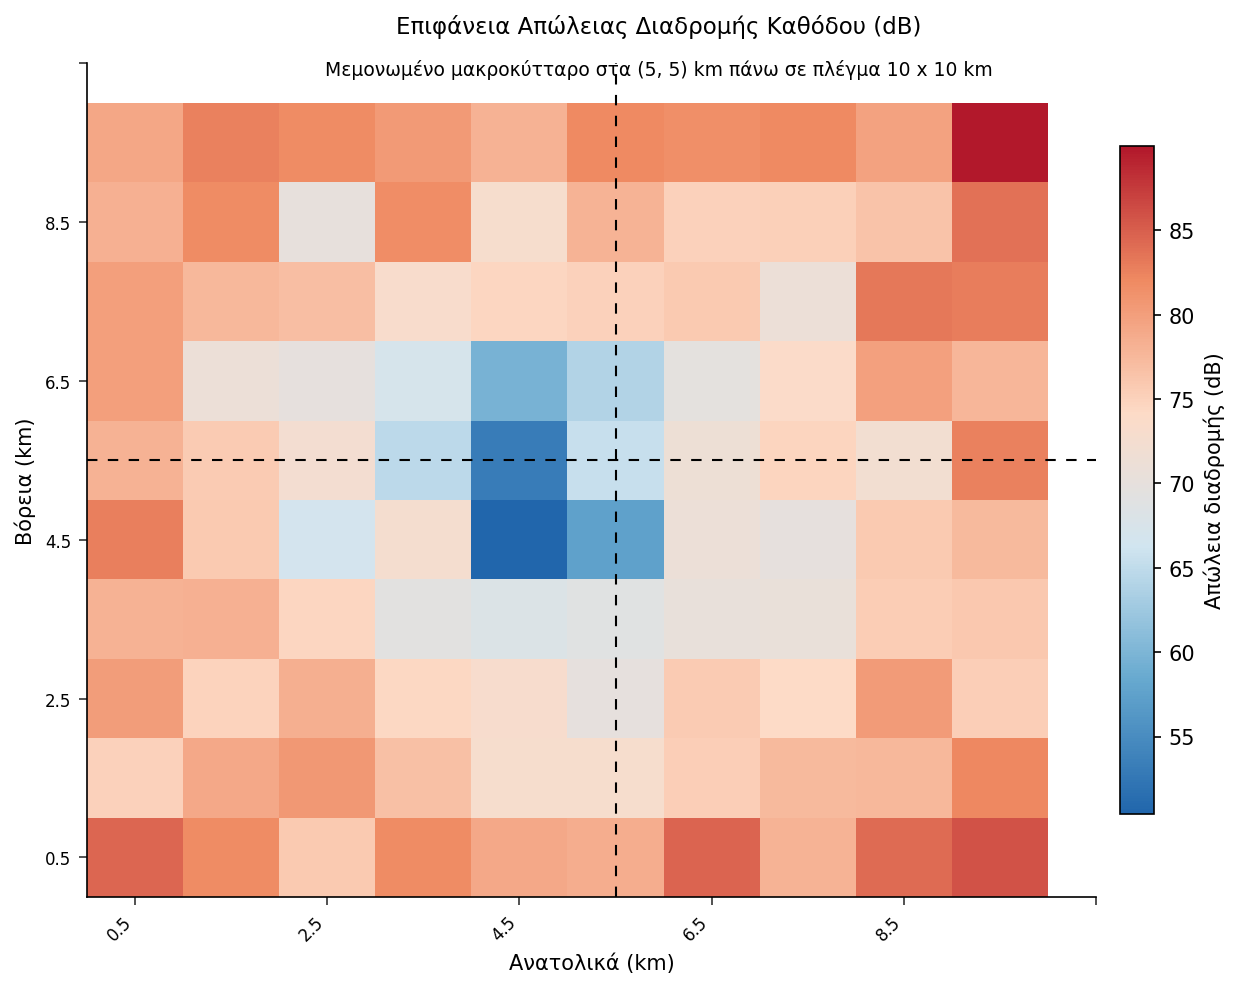

In [4]:
ODS GRAPHICS ON;
TITLE "Επιφάνεια Απώλειας Διαδρομής Καθόδου (dB)";
title2 "Μεμονωμένο μακροκύτταρο στα (5, 5) km πάνω σε πλέγμα 10 x 10 km";

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=pathloss_grid;
   heatmapparm x=east_km y=north_km colorresponse=path_loss /
        name="pl"
        colormodel=(CX2166AC CX67A9CF CXD1E5F0 CXFDDBC7 CXEF8A62 CXB2182B);
   gradlegend "pl" / TITLE="Απώλεια διαδρομής (dB)";
   REFLINE 5 / AXIS=x LINEATTRS=(color=black pattern=shortdash);
   REFLINE 5 / AXIS=y LINEATTRS=(color=black pattern=shortdash);
   XAXIS VALUES=(0 2 4 6 8 10) ΕΤΙΚΕΤΑ="Ανατολικά (km)";
   YAXIS VALUES=(0 2 4 6 8 10) ΕΤΙΚΕΤΑ="Βόρεια (km)";
ΕΚΤΕΛΕΣΗ;

TITLE; title2;

## Βήμα 5 — Ανάλυση κατηγορίας κάλυψης

Μια διαφάνεια ενημέρωσης θέλει επίσης τον βασικό διαχωρισμό: τι ποσοστό του αποτυπώματος είναι Ισχυρή, Επαρκής ή Ασθενής. Ένα `VBAR` της ταξινόμησης `zone` δίνει αυτό με μια ματιά και συνοδεύει την επιφάνεια ισοϋψών παραπάνω.

                                               Ανάλυση Κατηγορίας Κάλυψης                                               




NOTE: Option TITLE changed to Ανάλυση Κατηγορίας Κάλυψης.
NOTE: PROC SGPLOT data=pathloss_grid

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


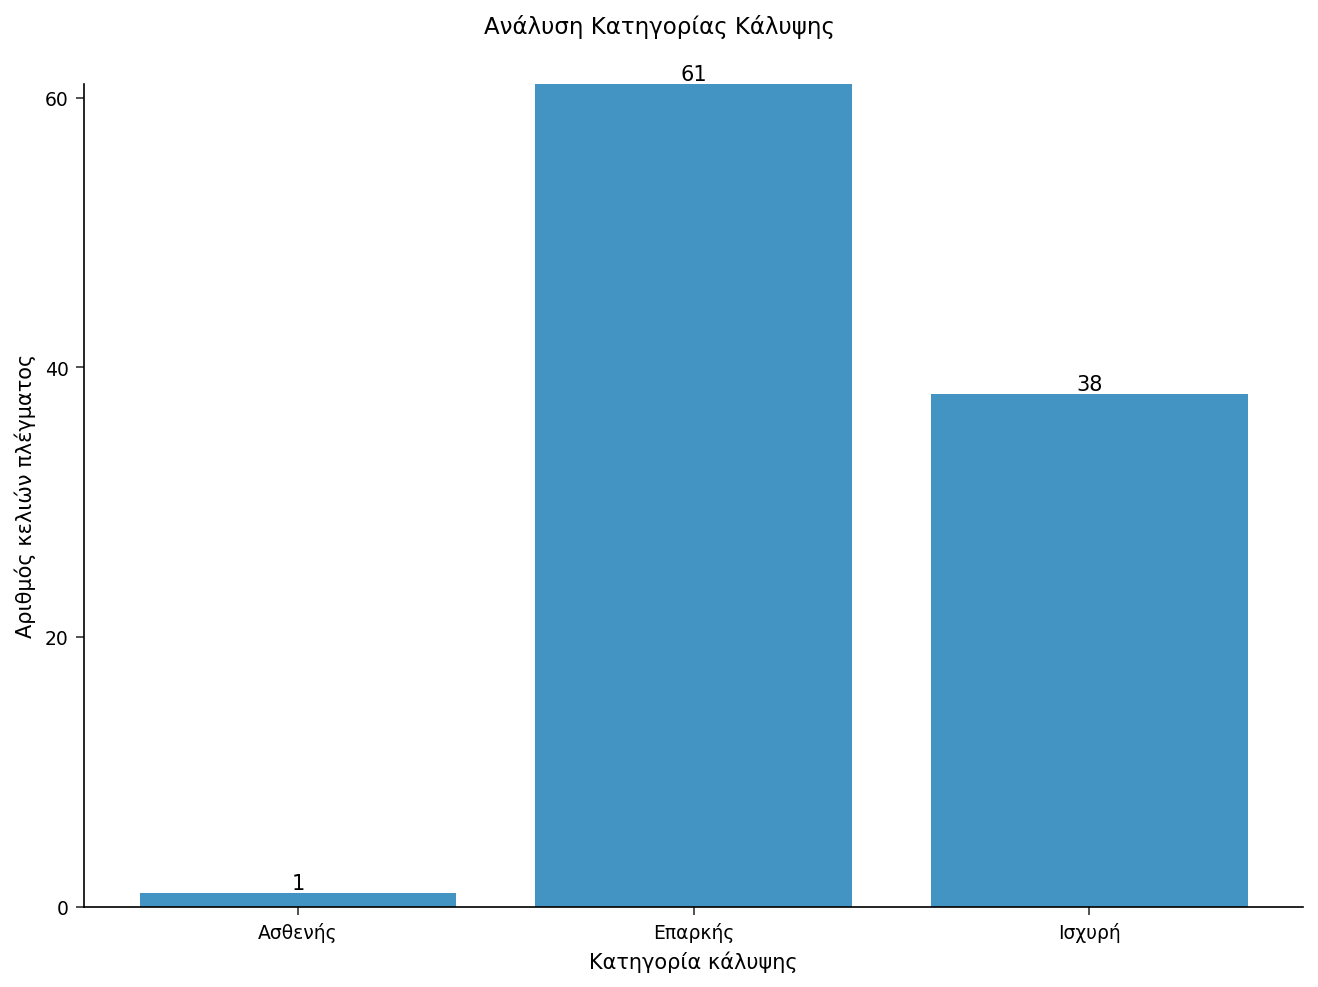

In [5]:
TITLE "Ανάλυση Κατηγορίας Κάλυψης";

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=pathloss_grid;
   VBAR zone / DATALABEL fillattrs=(color=CX4393C3) NOOUTLINE;
   XAXIS ΕΤΙΚΕΤΑ="Κατηγορία κάλυψης";
   YAXIS ΕΤΙΚΕΤΑ="Αριθμός κελιών πλέγματος" VALUES=(0 20 40 60);
ΕΚΤΕΛΕΣΗ;

TITLE;

## Ερμηνεία των αποτελεσμάτων

Η επιφάνεια ισοϋψών επιβεβαιώνει την αναμενόμενη φυσική διάδοσης. Η απώλεια διαδρομής είναι χαμηλότερη σε μια στενή **μπλε λεκάνη γύρω από τον πύργο στα (5, 5) km** — τη ζώνη «Ισχυρή» όπου το λαμβανόμενο σήμα είναι το καλύτερο — και αυξάνεται με τον λογάριθμο της απόστασης προς τις γωνίες. Επειδή εισαγάγαμε λογαριθμοκανονική διαλείπουσα σκίαση, οι ζώνες δεν είναι ομόκεντροι κύκλοι· τα ακανόνιστα κόκκινα κελιά κατά μήκος του ορίου είναι το άκρο με τη σκίαση.

Το αξιοποιήσιμο συμπέρασμα είναι το **μοναδικό κελί «Ασθενής» στα (9.5, 9.5) km (89.97 dB)**, η γωνία διαγώνια απέναντι από τον πύργο και το μόνο σημείο που ξεπερνά το όριο σχεδιασμού των 88 dB. Με **61 από τα 100 κελιά «Επαρκής» και μόλις 1 «Ασθενής»**, αυτό το μακροκύτταρο καλύπτει καλά την περιοχή εξυπηρέτησής του· η μοναδική τρύπα θα δικαιολογούσε **συμπλήρωση με μικροκύτταρο ή επανακλίση τομέα προς τη βορειοανατολική γωνία** μόνο αν επικάλυπτε ένα γνωστό σημείο υψηλής ζήτησης. Η επιφάνεια ισοϋψών είναι η σύνοψη έτοιμη για ενημέρωση· το ραβδόγραμμα κατηγορίας κάλυψης δίνει τον μονοαριθμητικό διαχωρισμό που αναφέρει προς τα πάνω ένας σχεδιαστής χωρητικότητας.